In [33]:
from google.colab import drive
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google.colab'

In [34]:
import pandas as pd
import numpy as np

In [35]:
# 원본 데이터 불러오기
trial_register = pd.read_csv('trial_register.csv')
trial_access_log = pd.read_csv('trial_access_log.csv')
trial_visit_info = pd.read_csv('trial_visit_info.csv')
trial_payment = pd.read_csv('trial_payment.csv')
site_area = pd.read_csv('site_area.csv')

# THIS IS 테이블별 전처리 (숨겨진 셀 13개 한번에 실행하세요)

### trial_register

In [36]:
# trial_date -> datetime 변환
trial_register['trial_date'] = pd.to_datetime(trial_register['trial_date'])

# user_uuid 기준, 가장 최근 trial_date인 행만 남김
trial_register = (trial_register.sort_values('trial_date', ascending=False).drop_duplicates(subset='user_uuid', keep='first'))
trial_register.duplicated().sum() # 중복치 0됨

0

### trial_payment

In [37]:
# 중복 결제 user_uuid 제거
trial_payment = trial_payment.drop_duplicates()
trial_payment.duplicated().sum() # 중복치 0됨

0

### trial_visit_info

In [38]:
# 모든 변수 값이 동일한 행에 대해 1건만 남기고 제거
trial_visit_info = trial_visit_info.drop_duplicates(keep='first')
trial_visit_info.duplicated().sum() # 중복치 0됨

0

In [39]:
# 문자열 -> datetime 변환, 마이크로초 삭제 (나중에 초단위까지 삭제하려면 replace 인자에 second=0 추가)

cols = ['date', 'first_enter_time', 'last_leave_time']

def datetime_changer(df, col_list):
    for col in col_list:
        df[col] = pd.to_datetime(df[col], errors='coerce')
        df[f'{col}'] = df[col].apply(
            lambda dt: dt.replace(microsecond=0) if pd.notnull(dt) else pd.NaT
        )
    return df

datetime_changer(trial_visit_info, cols)

trial_visit_info.head(3)

,site_id,date,stay_time,stay_time_second,first_enter_time,last_leave_time,user_uuid
0,1,2023-12-23,01:11:19.983486,4279,2023-12-23 16:11:25,2023-12-23 17:25:32,939fc566-61cd-47f0-a3ce-e2936fdcff73
1,1,2023-12-24,04:35:10.361341,16510,2023-12-24 16:10:45,2023-12-24 20:53:34,939fc566-61cd-47f0-a3ce-e2936fdcff73
2,1,2023-12-25,02:09:54.117163,7794,2023-12-25 10:19:47,2023-12-25 12:39:51,939fc566-61cd-47f0-a3ce-e2936fdcff73


In [40]:
# 문자열 -> timedelta 변환, 마이크로초 삭제
trial_visit_info['stay_time'] = trial_visit_info['stay_time'].apply(
    lambda x: x.split('.')[0] if pd.notnull(x) else None
)

trial_visit_info['stay_time'] = pd.to_timedelta(trial_visit_info['stay_time'])

trial_visit_info.head(3)


,site_id,date,stay_time,stay_time_second,first_enter_time,last_leave_time,user_uuid
0,1,2023-12-23,0 days 01:11:19,4279,2023-12-23 16:11:25,2023-12-23 17:25:32,939fc566-61cd-47f0-a3ce-e2936fdcff73
1,1,2023-12-24,0 days 04:35:10,16510,2023-12-24 16:10:45,2023-12-24 20:53:34,939fc566-61cd-47f0-a3ce-e2936fdcff73
2,1,2023-12-25,0 days 02:09:54,7794,2023-12-25 10:19:47,2023-12-25 12:39:51,939fc566-61cd-47f0-a3ce-e2936fdcff73


In [41]:
# 무료체험 3일 초과하는 경우, 마지막 일자에 해당되는 로우만 삭제
# 1. user_uuid 및 date 기준으로 중복 제거 -> user id별 고유 방문일 확인
user_date = trial_visit_info[['user_uuid', 'date']].drop_duplicates()

# 2. 유저별 고유 방문일 수 계산
visit_day_count = user_date['user_uuid'].value_counts()

# 3. 4일 이상 방문한 유저 추출 (visit_day_count가 4이상인 조건을 넣어서 추출)
over_3day_users = visit_day_count[visit_day_count > 3].index

# 4. 유저별 마지막 방문일 검색
last_visit_date = user_date[user_date['user_uuid'].isin(over_3day_users)] \
                    .groupby('user_uuid')['date'].max().reset_index()

# 5. 마지막 날 row만 삭제 조건 만들기 (user_uuid + date 조합)
last_visit_set = set(tuple(x) for x in last_visit_date.to_numpy())

# 6. 조건에 해당하는 row 제거
trial_visit_info = trial_visit_info[~trial_visit_info[['user_uuid', 'date']].apply(tuple, axis=1).isin(last_visit_set)]
trial_visit_info.shape

(11342, 7)

### trial_access_log

In [42]:
# id(index) 제거
trial_access_log = trial_access_log.drop(columns='id')
trial_access_log.head(3)

,checkin,cdate,site_id,user_uuid
0,1,2023-07-07 07:11:55.201673,49,cacd0adb-2c87-450f-8a00-2b2ea6b8fa89
1,2,2023-07-06 15:15:58.761284,49,cacd0adb-2c87-450f-8a00-2b2ea6b8fa89
2,2,2023-07-07 14:10:41.848998,49,cacd0adb-2c87-450f-8a00-2b2ea6b8fa89


In [43]:
# 문자열 -> datetime 변환, 마이크로초 삭제 (나중에 초단위까지 삭제하려면 replace 인자에 second=0 추가)
trial_access_log['cdate'] = pd.to_datetime(
    trial_access_log['cdate'], errors='coerce'
)

trial_access_log['cdate'] = trial_access_log['cdate'].apply(
    lambda dt: dt.replace(microsecond=0) if pd.notnull(dt) else pd.NaT
)

trial_access_log.head(3)

,checkin,cdate,site_id,user_uuid
0,1,2023-07-07 07:11:55,49,cacd0adb-2c87-450f-8a00-2b2ea6b8fa89
1,2,2023-07-06 15:15:58,49,cacd0adb-2c87-450f-8a00-2b2ea6b8fa89
2,2,2023-07-07 14:10:41,49,cacd0adb-2c87-450f-8a00-2b2ea6b8fa89


In [44]:
# 정식 오픈 전 출입 로그 3건 제거
condition = (trial_access_log['site_id'] == 6) & (trial_access_log['cdate'] < '2021-11-16')

# 조건을 만족하는 행을 제외한 나머지만 남기기
trial_access_log = trial_access_log[~condition]

trial_access_log.shape

(63705, 4)

# 얼레벌레 1차 전처리 수정본(숨겨진 셀 15개 한번에 실행하세요)
    * 일단 건들지말고 그냥 돌려서 모델링 해보시고 문제 생기시면 기록해뒀다가 공유 부탁드립니다~

In [45]:
# 1. trial_register: 유저별 신청일, 요일/시간/주말 파생
register_feat = trial_register.copy()



access_uuids = set(trial_access_log['user_uuid'])
register_feat = register_feat[register_feat['user_uuid'].isin(access_uuids)]



register_feat['register_weekday'] = register_feat['trial_date'].dt.weekday
register_feat['register_is_weekend'] = register_feat['register_weekday'].isin([5,6]).astype(int)

register_feat.shape

(6025, 4)

In [46]:
# 2. trial_visit_info: 유저별 방문/체류 파생
visit = trial_visit_info.copy()


access_uuids = set(trial_access_log['user_uuid'])
visit = visit[visit['user_uuid'].isin(access_uuids)]


visit['weekday'] = visit['date'].dt.weekday
visit['is_weekend'] = visit['weekday'].isin([5,6]).astype(int)
visit['hour'] = visit['first_enter_time'].dt.hour

visit_feat = visit.groupby('user_uuid').agg(
    visit_days = ('date', 'nunique'),
    total_stay_time = ('stay_time_second', 'sum'),
    avg_stay_time = ('stay_time_second', 'mean'),
    std_stay_time = ('stay_time_second', 'std'),
    first_visit_date = ('date', 'min'),
    visit_weekdays = ('is_weekend', lambda x: 1 - x.mean()),  # 평일 방문 비율
    visit_weekend = ('is_weekend', 'max'),  # 주말 방문 경험 여부
    site_count = ('site_id', 'nunique'),
    preferred_site_id = ('site_id', lambda x: x.value_counts().idxmax())
).reset_index()

In [47]:
# 오전/오후/야간 비율
def hour_type(hour):
    if 6 <= hour < 12: return 'morning'
    elif 12 <= hour < 18: return 'afternoon'
    else: return 'night'
visit['hour_type'] = visit['hour'].apply(hour_type)
hour_pivot = visit.pivot_table(index='user_uuid', columns='hour_type', values='date', aggfunc='count', fill_value=0)
hour_pivot = hour_pivot.div(hour_pivot.sum(axis=1), axis=0).reset_index().rename_axis(None, axis=1)

visit_feat = visit_feat.merge(hour_pivot, on='user_uuid', how='left')

In [48]:
# 신청~첫 방문까지 소요 일수
register_feat = register_feat.merge(
    visit_feat[['user_uuid', 'first_visit_date']], on='user_uuid', how='left'
)
register_feat['first_visit_delay'] = (register_feat['first_visit_date'] - register_feat['trial_date']).dt.days
# 음수/결측/비정상값 마스킹 (예: -1, 0, 100일 이상 등)
register_feat['first_visit_delay'] = register_feat['first_visit_delay'].apply(lambda x: x if (x >= 0 and x < 100) else None)

In [49]:
# 3. trial_access_log: 입장/퇴장 카운트
access = trial_access_log.copy()


access_uuids = set(trial_access_log['user_uuid'])
access = access[access['user_uuid'].isin(access_uuids)]


entry_count = access[access['checkin'] == 1].groupby('user_uuid').size().rename('entry_count')
exit_count = access[access['checkin'] == 2].groupby('user_uuid').size().rename('exit_count')
access_feat = pd.concat([entry_count, exit_count], axis=1).fillna(0).reset_index()

In [50]:
# 4. site_area: 체류시간/면적, 넓은 지점만 방문 여부
visit_site = visit.merge(site_area, on='site_id', how='left')
site_density = visit_site.groupby('user_uuid').apply(
    lambda x: (x['stay_time_second'] / x['area_pyeong']).mean()
).rename('stay_density').reset_index()
# stay_density 이상치 마스킹 (음수, 99% 초과값 등)
q99 = site_density['stay_density'].quantile(0.99)
site_density['stay_density'] = site_density['stay_density'].apply(lambda x: x if (x >= 0 and x <= q99) else None)

C:\Users\ypsoo\AppData\Local\Temp\ipykernel_35460\2926743207.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  site_density = visit_site.groupby('user_uuid').apply(


In [51]:
big_site_ids = site_area[site_area['area_pyeong'] >= site_area['area_pyeong'].median()]['site_id']
is_big_site_user = visit_site.groupby('user_uuid')['site_id'].apply(
    lambda x: int(set(x).issubset(set(big_site_ids)))
).rename('is_big_site_user').reset_index()

In [52]:
# 5. 결제 타겟
target = trial_payment.copy()


access_uuids = set(trial_access_log['user_uuid'])
target = target[target['user_uuid'].isin(access_uuids)]


target = target[['user_uuid', 'is_payment']]
target.shape

(6025, 2)

In [53]:
# 6. 통합
def safe_merge(left, right, **kwargs):
    # user_uuid 기준 중복 제거 후 merge
    return left.drop_duplicates('user_uuid').merge(right.drop_duplicates('user_uuid'), on='user_uuid', **kwargs)

In [54]:
user_feat = safe_merge(register_feat, visit_feat, how='left')
user_feat = safe_merge(user_feat, access_feat, how='left')
user_feat = safe_merge(user_feat, site_density, how='left')
user_feat = safe_merge(user_feat, is_big_site_user, how='left')
user_feat = safe_merge(user_feat, target, how='left')

user_feat = user_feat.fillna(0)

In [55]:
print(register_feat.shape)
print(visit_feat.shape)
print(access_feat.shape)
print(site_density.shape)
print(is_big_site_user.shape)
print(target.shape)

(6025, 6)
(6022, 13)
(6025, 3)
(6022, 2)
(6022, 2)
(6025, 2)


In [56]:
# preferred_site_id 범주형 인코딩 (Label Encoding)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
user_feat['preferred_site_id_enc'] = le.fit_transform(user_feat['preferred_site_id'].astype(str))

In [57]:
# 날짜형 컬럼 제거 (trial_date, first_visit_date 등)
drop_cols = [col for col in user_feat.columns if any(x in col for x in ['date', 'trial_date', 'first_visit_date'])]
user_feat_final = user_feat.drop(columns=drop_cols)

In [60]:
# pytrends로 '공유오피스', '사무실 임대' 검색 트렌드 수집 및 예약일 매칭 (과부하 방지, 예외처리 포함)
from pytrends.request import TrendReq
import time
import random

# 1. 예약일(신청일) 추출 (user_uuid별 trial_date)
register_dates = register_feat[['user_uuid', 'trial_date']].copy()
register_dates['date'] = pd.to_datetime(register_dates['trial_date']).dt.date

# 2. 트렌드 데이터 수집 함수 (과부하 방지, 예외처리)
def get_trend_df(keyword, date_list):
    pytrends = TrendReq(hl='ko', tz=540)
    start = min(date_list)
    end = max(date_list)
    date_ranges = pd.date_range(start, end, freq='90D')
    if date_ranges[-1].date() != end:
        date_ranges = date_ranges.append(pd.DatetimeIndex([end]))
    trend_df_list = []
    for i in range(len(date_ranges)-1):
        d1 = date_ranges[i].strftime('%Y-%m-%d')
        d2 = date_ranges[i+1].strftime('%Y-%m-%d')
        for attempt in range(3):  # 최대 3회 재시도
            try:
                pytrends.build_payload([keyword], timeframe=f'{d1} {d2}')
                df = pytrends.interest_over_time().reset_index()
                if not df.empty:
                    trend_df_list.append(df)
                break
            except Exception as e:
                print(f"{keyword} {d1}~{d2} Error: {e}, {attempt+1}회 재시도")
                time.sleep(random.uniform(2, 6))
        time.sleep(random.uniform(1, 4))  # 과도한 요청 방지
    if trend_df_list:
        trend_df = pd.concat(trend_df_list, ignore_index=True)
        trend_df = trend_df.rename(columns={keyword: f'trend_{keyword}'})
        trend_df['date'] = pd.to_datetime(trend_df['date']).dt.date
        return trend_df[['date', f'trend_{keyword}']]
    else:
        return pd.DataFrame(columns=['date', f'trend_{keyword}'])

# 3. 트렌드 데이터 수집
unique_dates = sorted(register_dates['date'].unique())
trend_gongyu = get_trend_df('공유오피스', unique_dates)
trend_office = get_trend_df('사무실 임대', unique_dates)

# 4. 예약일 기준으로 트렌드 값 매칭
register_dates = register_dates.merge(trend_gongyu, on='date', how='left')
register_dates = register_dates.merge(trend_office, on='date', how='left')

# 4-1. trend 값 0을 NaN으로 바꾸고, interpolate로 선형 보간
register_dates['trend_공유오피스'] = register_dates['trend_공유오피스'].replace(0, np.nan).interpolate()
register_dates['trend_사무실 임대'] = register_dates['trend_사무실 임대'].replace(0, np.nan).interpolate()

# 5. user_uuid별 trend 컬럼을 user_feat에 추가
user_feat = user_feat.merge(register_dates[['user_uuid', 'trend_공유오피스', 'trend_사무실 임대']], on='user_uuid', how='left')

공유오피스 2021-05-01~2021-07-30 Error: The request failed: Google returned a response with code 429, 1회 재시도
공유오피스 2021-05-01~2021-07-30 Error: The request failed: Google returned a response with code 429, 2회 재시도
공유오피스 2021-05-01~2021-07-30 Error: The request failed: Google returned a response with code 429, 2회 재시도
공유오피스 2021-05-01~2021-07-30 Error: The request failed: Google returned a response with code 429, 3회 재시도
공유오피스 2021-05-01~2021-07-30 Error: The request failed: Google returned a response with code 429, 3회 재시도
공유오피스 2021-07-30~2021-10-28 Error: The request failed: Google returned a response with code 429, 1회 재시도
공유오피스 2021-07-30~2021-10-28 Error: The request failed: Google returned a response with code 429, 1회 재시도
공유오피스 2021-07-30~2021-10-28 Error: The request failed: Google returned a response with code 429, 2회 재시도
공유오피스 2021-07-30~2021-10-28 Error: The request failed: Google returned a response with code 429, 2회 재시도
공유오피스 2021-07-30~2021-10-28 Error: The request failed: Google re

KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt

# 날짜별 trend_공유오피스 평균 집계
trend_by_date = user_feat.groupby(user_feat['trial_date'].dt.date)['trend_공유오피스'].mean()

plt.figure(figsize=(14, 5))
plt.plot(trend_by_date.index, trend_by_date.values, marker='o', linestyle='-')
plt.title('Daily Average of trend_공유오피스')
plt.xlabel('Date')
plt.ylabel('Average trend_공유오피스')
plt.grid(True)
plt.tight_layout()
plt.show()

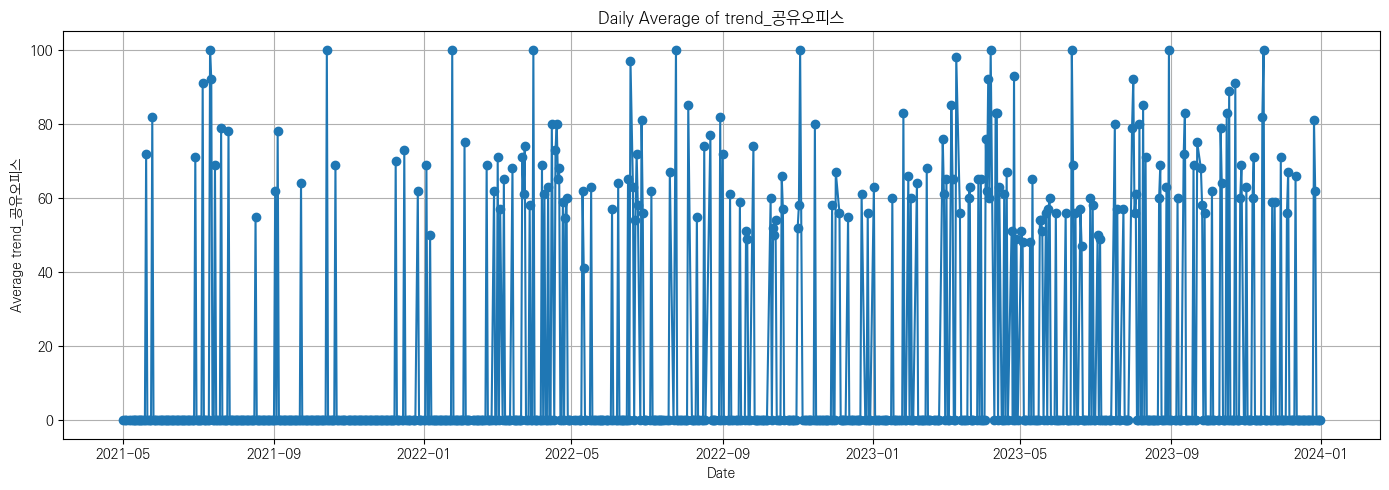

In [ ]:
import matplotlib.pyplot as plt

# 날짜별 trend_공유오피스 평균 집계
trend_by_date = user_feat.groupby(user_feat['trial_date'].dt.date)['trend_공유오피스'].mean()

plt.figure(figsize=(14, 5))
plt.plot(trend_by_date.index, trend_by_date.values, marker='o', linestyle='-')
plt.title('Daily Average of trend_공유오피스')
plt.xlabel('Date')
plt.ylabel('Average trend_공유오피스')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# trend_공유오피스가 0이 아닌 날짜만 추출
nonzero_dates = user_feat[user_feat['trend_공유오피스'] > 0]['trial_date'].dt.date.unique()
print(sorted(nonzero_dates)[:10])  # 앞부분 10개만 예시 출력

# 혹은 trend_공유오피스가 0이 아닌 날짜의 요일 분포 확인
import pandas as pd
user_feat['weekday'] = user_feat['trial_date'].dt.weekday
print(user_feat[user_feat['trend_공유오피스'] > 0]['weekday'].value_counts())

[datetime.date(2021, 5, 20), datetime.date(2021, 5, 25), datetime.date(2021, 6, 29), datetime.date(2021, 7, 5), datetime.date(2021, 7, 11), datetime.date(2021, 7, 12), datetime.date(2021, 7, 15), datetime.date(2021, 7, 20), datetime.date(2021, 7, 26), datetime.date(2021, 8, 17)]
weekday
0    484
1    278
2    254
3    225
4     74
5     28
6     19
Name: count, dtype: int64


,trial_date,register_weekday,register_is_weekend,first_visit_delay,visit_days,total_stay_time,avg_stay_time,std_stay_time,visit_weekdays,visit_weekend,...,morning,night,entry_count,exit_count,stay_density,is_big_site_user,is_payment,preferred_site_id_enc,trend_공유오피스,trend_사무실 임대
count,6111,6111.000000,6111.000000,6111.000000,6111.000000,6111.000000,6111.000000,6111.000000,6111.000000,6111.000000,...,6111.000000,6111.000000,6111.000000,6111.000000,6111.000000,6111.000000,6111.000000,6111.000000,6111.000000,4623.000000
mean,2022-08-29 08:15:18.998526976,2.348552,0.150712,0.889871,1.779087,30444.179021,16118.694041,3710.459296,0.783104,0.303224,...,0.261760,0.261198,5.363116,5.264932,163.076150,0.719522,0.387171,4.862543,15.104238,1.304780
min,2021-05-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2021-12-10 12:00:00,1.000000,0.000000,0.000000,1.000000,11180.500000,8370.000000,0.000000,0.500000,0.000000,...,0.000000,0.000000,2.000000,2.000000,73.319444,0.000000,0.000000,3.000000,0.000000,0.000000
50%,2022-08-23 00:00:00,2.000000,0.000000,1.000000,2.000000,23209.000000,14647.500000,763.675324,1.000000,0.000000,...,0.000000,0.000000,4.000000,4.000000,133.671111,1.000000,0.000000,4.000000,0.000000,0.000000
75%,2023-05-08 00:00:00,4.000000,0.000000,1.000000,2.000000,43102.000000,21962.166667,5468.790007,1.000000,1.000000,...,0.500000,0.500000,7.000000,7.000000,217.501667,1.000000,1.000000,8.000000,0.000000,0.000000
max,2023-12-31 00:00:00,6.000000,1.000000,2.000000,3.000000,176127.000000,83865.000000,52323.780487,1.000000,1.000000,...,1.000000,1.000000,64.000000,62.000000,642.940000,1.000000,1.000000,9.000000,100.000000,100.000000
std,NaN,1.889309,0.357797,0.656689,0.795627,25568.411182,10558.684982,6128.885731,0.358389,0.459689,...,0.394362,0.397552,4.807714,4.749056,123.825201,0.449269,0.487143,2.758903,28.871493,10.713163


In [58]:
user_feat_final.to_csv('user_feat_final.csv', index=False)

In [ ]:
# 최종 데이터 info/describe 점검
print('최종 user_feat_final info:')
user_feat_final.info()
print('\n최종 user_feat_final describe:')
display(user_feat_final.describe(include='all'))
user_feat_final.head()

최종 user_feat_final info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6025 entries, 0 to 6024
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_uuid              6025 non-null   object 
 1   register_weekday       6025 non-null   int32  
 2   register_is_weekend    6025 non-null   int32  
 3   first_visit_delay      6025 non-null   float64
 4   visit_days             6025 non-null   float64
 5   total_stay_time        6025 non-null   float64
 6   avg_stay_time          6025 non-null   float64
 7   std_stay_time          6025 non-null   float64
 8   visit_weekdays         6025 non-null   float64
 9   visit_weekend          6025 non-null   float64
 10  site_count             6025 non-null   float64
 11  preferred_site_id      6025 non-null   float64
 12  afternoon              6025 non-null   float64
 13  morning                6025 non-null   float64
 14  night                  6025 non

,user_uuid,register_weekday,register_is_weekend,first_visit_delay,visit_days,total_stay_time,avg_stay_time,std_stay_time,visit_weekdays,visit_weekend,...,preferred_site_id,afternoon,morning,night,entry_count,exit_count,stay_density,is_big_site_user,is_payment,preferred_site_id_enc
count,6025,6025.000000,6025.000000,6025.000000,6025.000000,6025.000000,6025.000000,6025.000000,6025.000000,6025.000000,...,6025.000000,6025.000000,6025.000000,6025.000000,6025.000000,6025.000000,6025.000000,6025.000000,6025.000000,6025.000000
unique,6025,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,acf3e288-4487-492b-9477-df149fb72e83,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,2.344564,0.152863,0.890954,1.778755,30359.800664,16090.793021,3682.162279,0.783826,0.302407,...,7.417427,0.476852,0.261928,0.260722,5.334772,5.238672,163.127065,0.720664,0.387718,4.862739
std,NaN,1.898079,0.359885,0.657392,0.795080,25395.547944,10494.127906,6083.235736,0.357958,0.459339,...,11.582325,0.444619,0.394768,0.397416,4.741557,4.685827,123.878607,0.448710,0.487270,2.757685
min,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,1.000000,0.000000,0.000000,1.000000,11181.000000,8371.000000,0.000000,0.500000,0.000000,...,2.000000,0.000000,0.000000,0.000000,2.000000,2.000000,73.386667,0.000000,0.000000,3.000000
50%,NaN,2.000000,0.000000,1.000000,2.000000,23190.000000,14641.333333,759.116153,1.000000,0.000000,...,3.000000,0.500000,0.000000,0.000000,4.000000,4.000000,133.775000,1.000000,0.000000,4.000000
75%,NaN,4.000000,0.000000,1.000000,2.000000,43009.000000,21933.333333,5444.015108,1.000000,1.000000,...,6.000000,1.000000,0.500000,0.500000,7.000000,7.000000,217.360000,1.000000,1.000000,8.000000


,user_uuid,register_weekday,register_is_weekend,first_visit_delay,visit_days,total_stay_time,avg_stay_time,std_stay_time,visit_weekdays,visit_weekend,...,preferred_site_id,afternoon,morning,night,entry_count,exit_count,stay_density,is_big_site_user,is_payment,preferred_site_id_enc
0,acf3e288-4487-492b-9477-df149fb72e83,6,1,0.0,2.0,38342.0,19171.000000,6570.436211,0.500000,1.0,...,6.0,0.5,0.5,0.0,12.0,14.0,127.806667,1.0,0,9
1,a75029c4-57c6-4f98-bb8f-c669e3371eaa,6,1,1.0,1.0,9633.0,9633.000000,0.000000,1.000000,0.0,...,17.0,0.0,1.0,0.0,4.0,4.0,192.660000,0.0,0,2
2,0e58ea5a-ebe4-48cb-b31b-d02a4f350cf8,6,1,0.0,2.0,38522.0,19261.000000,12092.940172,0.500000,1.0,...,3.0,1.0,0.0,0.0,8.0,8.0,128.406667,1.0,1,4
3,a806f6d6-4bea-40df-b870-212859386e9d,5,1,0.0,2.0,8461.0,4230.500000,3507.956741,0.000000,1.0,...,2.0,0.0,0.0,1.0,3.0,3.0,42.305000,1.0,0,3
4,e9b1a5df-d70c-4ccf-af22-64fdae98d3a2,5,1,0.0,3.0,38932.0,12977.333333,1249.509637,0.333333,1.0,...,4.0,1.0,0.0,0.0,12.0,12.0,129.773333,1.0,0,5


In [ ]:
user_feat_final.isna().sum()

user_uuid                0
register_weekday         0
register_is_weekend      0
first_visit_delay        0
visit_days               0
total_stay_time          0
avg_stay_time            0
std_stay_time            0
visit_weekdays           0
visit_weekend            0
site_count               0
preferred_site_id        0
afternoon                0
morning                  0
night                    0
entry_count              0
exit_count               0
stay_density             0
is_big_site_user         0
is_payment               0
preferred_site_id_enc    0
dtype: int64

# 여기서부터 모델링을 하세요
    * 합쳐진 테이블명 : user_feat_final

In [ ]:
# 머신러닝 모델링: 여러 모델, 앙상블, 성능 비교
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# 1. 데이터 준비 (feature/target 분리, train/valid split)
X = user_feat_final.drop(columns=['user_uuid', 'is_payment'])
y = user_feat_final['is_payment']

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. 스케일링 (LogisticRegression만 적용)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

# 3. 여러 모델 정의
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(n_estimators=100, random_state=42)
}

# 4. 모델별 학습 및 평가
results = []
for name, model in models.items():
    if name == 'LogisticRegression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_valid_scaled)
        y_proba = model.predict_proba(X_valid_scaled)[:,1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_valid)
        y_proba = model.predict_proba(X_valid)[:,1]
    acc = accuracy_score(y_valid, y_pred)
    auc = roc_auc_score(y_valid, y_proba)
    f1 = f1_score(y_valid, y_pred)
    results.append({'Model': name, 'Accuracy': acc, 'AUC': auc, 'F1': f1})

# 5. 앙상블(Voting) 모델
voting = VotingClassifier(
    estimators=[
        ('rf', models['RandomForest']),
        ('gb', models['GradientBoosting']),
        ('xgb', models['XGBoost']),
        ('lgbm', models['LightGBM'])
    ],
    voting='soft'
)
voting.fit(X_train, y_train)
y_pred = voting.predict(X_valid)
y_proba = voting.predict_proba(X_valid)[:,1]
acc = accuracy_score(y_valid, y_pred)
auc = roc_auc_score(y_valid, y_proba)
f1 = f1_score(y_valid, y_pred)
results.append({'Model': 'VotingEnsemble', 'Accuracy': acc, 'AUC': auc, 'F1': f1})

# 6. 결과 표 출력
score_df = pd.DataFrame(results).sort_values('AUC', ascending=False).reset_index(drop=True)
print('모델별 성능 비교 (Validation Set)')
display(score_df)

# 7. 최고 성능 모델 confusion matrix 시각화
best_model_name = score_df.iloc[0]['Model']
if best_model_name == 'VotingEnsemble':
    best_model = voting
    y_pred_best = y_pred
else:
    best_model = models[best_model_name]
    if best_model_name == 'LogisticRegression':
        y_pred_best = best_model.predict(X_valid_scaled)
    else:
        y_pred_best = best_model.predict(X_valid)
cm = confusion_matrix(y_valid, y_pred_best)
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'{best_model_name} Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Exception in thread Thread-4 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\ypsoo\anaconda3\Lib\threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "c:\Users\ypsoo\anaconda3\Lib\site-packages\ipykernel\ipkernel.py", line 766, in run_closure
    _threading_Thread_run(self)
  File "c:\Users\ypsoo\anaconda3\Lib\threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\ypsoo\anaconda3\Lib\subprocess.py", line 1597, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "<frozen codecs>", line 322, in decode
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xc0 in position 4: invalid start byte


[LightGBM] [Info] Number of positive: 1869, number of negative: 2951
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001022 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1159
[LightGBM] [Info] Number of data points in the train set: 4820, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.387759 -> initscore=-0.456741
[LightGBM] [Info] Start training from score -0.456741
[LightGBM] [Info] Number of positive: 1869, number of negative: 2951
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000202 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1159
[LightGBM] [Info] Number of data points in the train set: 4820, number of used features: 19
[LightGBM] [Info] [binar

,Model,Accuracy,AUC,F1
0,GradientBoosting,0.643983,0.640331,0.382734
1,VotingEnsemble,0.650622,0.631758,0.442384
2,RandomForest,0.644813,0.631593,0.467662
3,LogisticRegression,0.641494,0.628779,0.377522
4,LightGBM,0.638174,0.620199,0.421751
5,XGBoost,0.616598,0.596905,0.446043


최고 성능 모델: GradientBoosting Confusion Matrix
[[643  95]
 [334 133]]


ValueError: could not convert string to float: '67842c87-4c17-4131-b7bd-88ddb35cb7ef'

In [61]:
# pytrends 과부하 방지: 7일 단위로 트렌드 수집, 긴 대기, User-Agent 지정, exponential backoff 적용
from pytrends.request import TrendReq
import time
import random
from datetime import timedelta

# 1. 예약일(신청일) 추출 (user_uuid별 trial_date)
register_dates = register_feat[['user_uuid', 'trial_date']].copy()
register_dates['date'] = pd.to_datetime(register_dates['trial_date']).dt.date

# 2. 7일 단위로 트렌드 데이터 수집 함수

def get_trend_df_weekly(keyword, date_list):
    pytrends = TrendReq(hl='ko', tz=540, requests_args={'headers': {'User-Agent': 'Mozilla/5.0'}})
    start = min(date_list)
    end = max(date_list)
    week_starts = pd.date_range(start, end, freq='7D')
    if week_starts[-1].date() != end:
        week_starts = week_starts.append(pd.DatetimeIndex([end]))
    trend_df_list = []
    for i in range(len(week_starts)-1):
        d1 = week_starts[i].strftime('%Y-%m-%d')
        d2 = week_starts[i+1].strftime('%Y-%m-%d')
        for attempt in range(5):  # 최대 5회 재시도
            try:
                pytrends.build_payload([keyword], timeframe=f'{d1} {d2}')
                df = pytrends.interest_over_time().reset_index()
                if not df.empty:
                    trend_df_list.append(df)
                break
            except Exception as e:
                wait = random.uniform(10, 20) * (attempt+1)  # exponential backoff
                print(f"{keyword} {d1}~{d2} Error: {e}, {attempt+1}회 재시도, {wait:.1f}초 대기")
                time.sleep(wait)
        time.sleep(random.uniform(10, 20))  # 과도한 요청 방지(10~20초)
    if trend_df_list:
        trend_df = pd.concat(trend_df_list, ignore_index=True)
        trend_df = trend_df.rename(columns={keyword: f'trend_{keyword}'})
        trend_df['date'] = pd.to_datetime(trend_df['date']).dt.date
        return trend_df[['date', f'trend_{keyword}']]
    else:
        return pd.DataFrame(columns=['date', f'trend_{keyword}'])

# 3. 트렌드 데이터 수집(7일 단위)
unique_dates = sorted(register_dates['date'].unique())
trend_gongyu = get_trend_df_weekly('공유오피스', unique_dates)
trend_office = get_trend_df_weekly('사무실 임대', unique_dates)

# 4. 예약일에 가장 가까운 트렌드 값 매칭(7일 단위)
def match_nearest_trend(df, trend_df, trend_col):
    trend_df = trend_df.sort_values('date')
    trend_dates = trend_df['date'].values
    trend_values = trend_df[trend_col].values
    def find_nearest(d):
        idx = (abs(trend_dates - d)).argmin()
        return trend_values[idx]
    df[trend_col] = df['date'].apply(lambda d: trend_df.iloc[(trend_df['date']-d).abs().argsort().iloc[0]][trend_col] if not trend_df.empty else np.nan)
    return df

register_dates = match_nearest_trend(register_dates, trend_gongyu, 'trend_공유오피스')
register_dates = match_nearest_trend(register_dates, trend_office, 'trend_사무실 임대')

# 4-1. trend 값 0을 NaN으로 바꾸고, interpolate로 선형 보간
register_dates['trend_공유오피스'] = register_dates['trend_공유오피스'].replace(0, np.nan).interpolate()
register_dates['trend_사무실 임대'] = register_dates['trend_사무실 임대'].replace(0, np.nan).interpolate()

# 5. user_uuid별 trend 컬럼을 user_feat에 추가
user_feat = user_feat.merge(register_dates[['user_uuid', 'trend_공유오피스', 'trend_사무실 임대']], on='user_uuid', how='left')

공유오피스 2021-05-01~2021-05-08 Error: The request failed: Google returned a response with code 429, 1회 재시도, 16.7초 대기
공유오피스 2021-05-01~2021-05-08 Error: The request failed: Google returned a response with code 429, 2회 재시도, 21.8초 대기
공유오피스 2021-05-01~2021-05-08 Error: The request failed: Google returned a response with code 429, 2회 재시도, 21.8초 대기


KeyboardInterrupt: 

공유오피스 2022-01-01~2022-01-08 Error: The request failed: Google returned a response with code 429, 1회 재시도, 12.4초 대기
공유오피스 2022-01-01~2022-01-08 Error: The request failed: Google returned a response with code 429, 2회 재시도, 38.0초 대기
공유오피스 2022-01-01~2022-01-08 Error: The request failed: Google returned a response with code 429, 2회 재시도, 38.0초 대기
